<a href="https://colab.research.google.com/github/mkannnn/Mahesh_INFO4670_Spring2026/blob/main/Assignment3_AssociationRuleMining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


In [5]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [6]:
# write your answer here
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import networkx as nx

df = pd.read_csv('bread_basket.csv')

## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [7]:
# write your answer here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   transaction      20507 non-null  int64 
 1   item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   time             20507 non-null  object
 4   period_day       20507 non-null  object
 5   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(5)
memory usage: 961.4+ KB


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [8]:
# write your answer here
df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

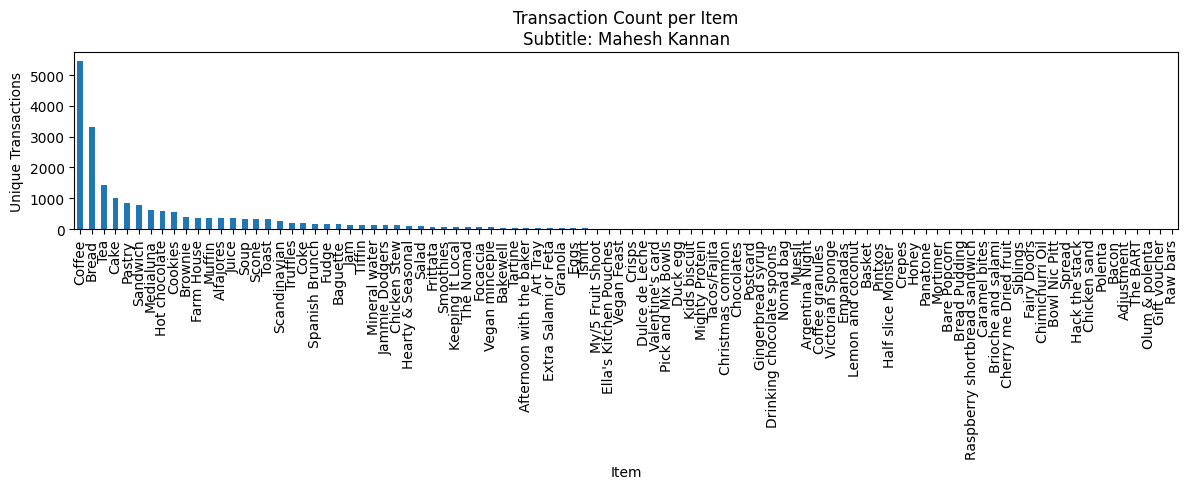

In [9]:
# c) Bar plot of transaction counts per item
subtitle = "Mahesh Kannan"  # <-- EDIT THIS
item_counts = df['item'].value_counts().sort_values(ascending=False) # <-- EDIT THIS
                 # .sort_values(ascending=False))

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [10]:
# write your answer here
item_counts['Coffee,Tea,Alfajores,Juice,Chicken Stew'.split(',')]

,count
item,
Coffee,5471
Tea,1435
Alfajores,369
Juice,369
Chicken Stew,123


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [11]:
# write your answer here
basket = (df.groupby(by='transaction')['item'].apply(list)
         .reset_index().sort_values('transaction')['item'].tolist())
basket

te_a = TransactionEncoder()
oht_a = pd.DataFrame(te_a.fit(basket).transform(basket), columns=te_a.columns_).astype(bool)
oht_a

freq_a = fpgrowth(oht_a, min_support=0.01, use_colnames=True)
freq_a

,support,itemsets
0,0.327205,(Bread)
1,0.029054,(Scandinavian)
2,0.058320,(Hot chocolate)
3,0.054411,(Cookies)
4,0.015003,(Jam)
...,...,...
56,0.019651,"(Brownie, Coffee)"
57,0.010777,"(Brownie, Bread)"
58,0.023666,"(Coffee, Toast)"
59,0.018067,"(Scone, Coffee)"


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [12]:
# write your answer here
rules_a = association_rules(freq_a, metric='confidence', min_threshold=0.1)
x = rules_a['antecedents consequents support confidence lift'.split()].sort_values(['lift', 'confidence'], ascending=False)
x


,antecedents,consequents,support,confidence,lift
29,"(Tea, Coffee)",(Cake),0.010037,0.201271,1.937977
5,(Hot chocolate),(Cake),0.011410,0.195652,1.883874
4,(Cake),(Hot chocolate),0.011410,0.109868,1.883874
25,(Tea),(Cake),0.023772,0.166667,1.604781
24,(Cake),(Tea),0.023772,0.228891,1.604781
41,(Toast),(Coffee),0.023666,0.704403,1.472431
14,(Pastry),"(Coffee, Bread)",0.011199,0.130061,1.444872
13,"(Coffee, Bread)",(Pastry),0.011199,0.124413,1.444872
34,(Sandwich),(Tea),0.014369,0.200000,1.402222
33,(Tea),(Sandwich),0.014369,0.100741,1.402222


In [42]:
y = x.copy()
y['consequents'] = y['consequents'].astype('string')
y['antecedents'] = y['antecedents'].astype('string')
y[(y['consequents'] == "frozenset({'Bread'})") & (y['antecedents'] == "frozenset({'Cake', 'Coffee'})")]

,antecedents,consequents,support,confidence,lift
30,"frozenset({'Cake', 'Coffee'})",frozenset({'Bread'}),0.010037,0.183398,0.560497


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:*

The rule is showing there is a negative association between Coffee/Cake and Bread. People who buy coffee and cake are less likely to also purchase bread.

- **Support**: Only about 1% of all transactions contain Coffee, Cake and Bread together.
- **Confidence**: Among the people who bought Coffee and Cake, only about 18% of them also bought Bread.
- **Lift**: The lift is less than 1 indicating that the items appear together less frequently than random chance.